
--- Starting Iterative Imputer for CE ---
[IterativeImputer] Completing matrix with shape (975, 14)
[IterativeImputer] Ending imputation round 1/50, elapsed time 0.06
[IterativeImputer] Change: 15.529294881081789, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imputation round 2/50, elapsed time 0.08
[IterativeImputer] Change: 0.6784949734793845, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imputation round 3/50, elapsed time 0.10
[IterativeImputer] Change: 0.19395577609180376, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imputation round 4/50, elapsed time 0.12
[IterativeImputer] Change: 0.13425010897263967, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imputation round 5/50, elapsed time 0.14
[IterativeImputer] Change: 0.11232886731212072, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imputation round 6/50, elapsed time 0.17
[IterativeImputer] Change: 0.08831946796734202, scaled tolerance: 0.00374259 
[IterativeImputer] Ending imput

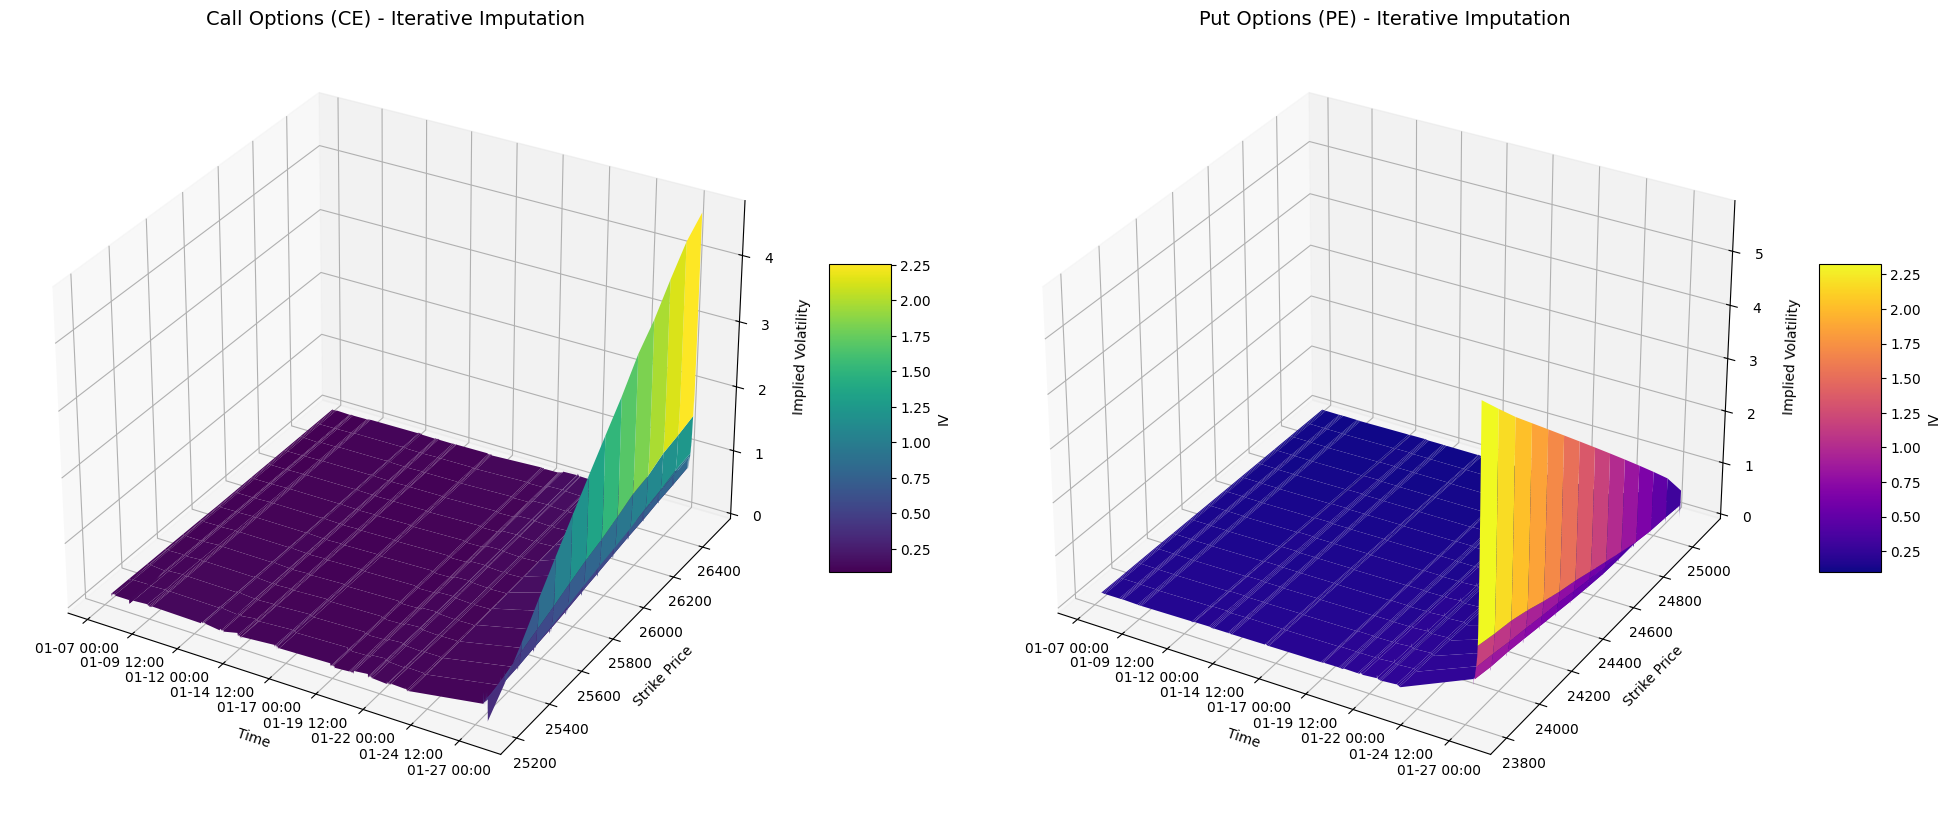

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def process_with_sklearn_imputer(file_path):
    #import data
    df = pd.read_csv(file_path)
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

    

    # Matrix Imputation Function

    def apply_iterative_impute(df_subset, option_type):
        cols = [col for col in df_subset.columns if col.endswith(option_type)]
        
        # Extract numeric strikes and sort them
        strikes = [int(col.replace('NIFTY27JAN26', '').replace(option_type, '')) for col in cols]
        sorted_indices = np.argsort(strikes)
        strikes = np.array(strikes)[sorted_indices]
        sorted_cols = np.array(cols)[sorted_indices]
        
        df_opt = df_subset[sorted_cols].copy()
        matrix_with_nans = df_opt.values
        
        print(f"\n--- Starting Iterative Imputer for {option_type} ---")
        
        # Apply the scikit learn imputer
        # verbose=2 will print the progress to check if the code hasnt freezed
        imputer = IterativeImputer(max_iter=50, verbose=2, random_state=42)
        matrix_filled = imputer.fit_transform(matrix_with_nans)
        
        # Convert back to DataFrame
        df_filled = pd.DataFrame(matrix_filled, columns=sorted_cols, index=df_opt.index)
        
        return df_filled, strikes, sorted_cols
 # =====================================
    # 2. Run for both CE and PE
    
    df_ce_filled, ce_strikes, ce_cols = apply_iterative_impute(df, 'CE')
    df_pe_filled, pe_strikes, pe_cols = apply_iterative_impute(df, 'PE')

    # Combine back into a single dataframe
    df_filled = df.copy()
    for col in ce_cols:
        df_filled[col] = df_ce_filled[col]
    for col in pe_cols:
        df_filled[col] = df_pe_filled[col]

    # Save the final dataset
    df_filled.to_csv('filled_dataset.csv', index=False)
    print("\n saved 'filled_dataset.csv' ")
# ================================================

    
    # 3. Plott Both Surfaces
    fig = plt.figure(figsize=(20, 8))
    
    # Meshgrids for plotting
    X_num = mdates.date2num(df['datetime'].values)
    X_ce_num, Y_ce = np.meshgrid(X_num, ce_strikes)
    X_pe_num, Y_pe = np.meshgrid(X_num, pe_strikes)

    Z_ce = df_ce_filled.values.T
    Z_pe = df_pe_filled.values.T

    # --- Plot CE Surface ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X_ce_num, Y_ce, Z_ce, cmap='viridis', edgecolor='none')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax1.set_title('Call Options (CE) - Iterative Imputation', fontsize=14)
    ax1.set_xlabel('\nTime')
    ax1.set_ylabel('\nStrike Price')
    ax1.set_zlabel('\nImplied Volatility')
    fig.colorbar(surf1, ax=ax1, shrink=0.4, aspect=5, label='IV')

    # --- Plot PE Surface ---
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X_pe_num, Y_pe, Z_pe, cmap='plasma', edgecolor='none')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax2.set_title('Put Options (PE) - Iterative Imputation', fontsize=14)
    ax2.set_xlabel('\nTime')
    ax2.set_ylabel('\nStrike Price')
    ax2.set_zlabel('\nImplied Volatility')
    fig.colorbar(surf2, ax=ax2, shrink=0.4, aspect=5, label='IV')

    plt.tight_layout()
    plt.show()

# Execute
if __name__ == "__main__":
    process_with_sklearn_imputer('dataset.csv')